In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

In [13]:
import pandas as pd

# Load the S20 dataset
df = pd.read_csv('filtered_features_s20.csv')

# Show dataset information
print("Dataset shape:", df.shape)

print("\nColumn names:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (4564, 96)

Column names:
0 : MagpieData minimum Number
1 : MagpieData maximum Number
2 : MagpieData range Number
3 : MagpieData mean Number
4 : MagpieData mode Number
5 : MagpieData minimum MendeleevNumber
6 : MagpieData maximum MendeleevNumber
7 : MagpieData range MendeleevNumber
8 : MagpieData mean MendeleevNumber
9 : MagpieData mode MendeleevNumber
10 : MagpieData minimum MeltingT
11 : MagpieData maximum MeltingT
12 : MagpieData range MeltingT
13 : MagpieData mean MeltingT
14 : MagpieData mode MeltingT
15 : MagpieData minimum Column
16 : MagpieData maximum Column
17 : MagpieData range Column
18 : MagpieData mean Column
19 : MagpieData avg_dev Column
20 : MagpieData mode Column
21 : MagpieData minimum Row
22 : MagpieData maximum Row
23 : MagpieData range Row
24 : MagpieData mean Row
25 : MagpieData mode Row
26 : MagpieData minimum CovalentRadius
27 : MagpieData maximum CovalentRadius
28 : MagpieData range CovalentRadius
29 : MagpieData mean CovalentRadius
30 : MagpieD

,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,MagpieData mode MendeleevNumber,...,MagpieData mode GSbandgap,MagpieData minimum GSmagmom,MagpieData maximum GSmagmom,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,5.0,8.0,3.0,6.8,8.0,72.0,87.0,15.0,81.0,87.0,...,0.0,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,12.0
1,5.0,8.0,3.0,6.8,8.0,72.0,87.0,15.0,81.0,87.0,...,0.0,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,12.0
2,5.0,8.0,3.0,6.8,8.0,72.0,87.0,15.0,81.0,87.0,...,0.0,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,12.0
3,5.0,8.0,3.0,6.8,8.0,72.0,87.0,15.0,81.0,87.0,...,0.0,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,12.0
4,5.0,8.0,3.0,6.8,8.0,72.0,87.0,15.0,81.0,87.0,...,0.0,0.0,0.0,0.0,0.0,12.0,166.0,154.0,73.6,12.0


In [14]:
# 1. Load the filtered dataset from Session S20
import pandas as pd

df = pd.read_csv('filtered_features_s20.csv')

# 2. Define target
target_column = 'MagpieData mean GSbandgap'

# 3. Create features (X) and target (y)
X = df.drop(columns=[target_column])
y = df[target_column]

# 4. Display results
print("Dataset shape:", df.shape)
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target column:", y.name)

Dataset shape: (4564, 96)
Features shape: (4564, 95)
Target shape: (4564,)
Target column: MagpieData mean GSbandgap


In [15]:
# 2. Recursive Feature Elimination (RFE) with Ridge
# Reduce the dataset down to the top 20 features
ridge = Ridge(alpha=1.0)
rfe = RFE(estimator=ridge, n_features_to_select=20)
X_rfe = rfe.fit_transform(X, y)

In [16]:
# Get the names of the top 20 selected features
top_features = X.columns[rfe.support_]
print(f"Top 20 features selected by RFE: \n{list(top_features)}")

Top 20 features selected by RFE: 
['MagpieData maximum Column', 'MagpieData mean Column', 'MagpieData avg_dev Column', 'MagpieData mean Electronegativity', 'MagpieData mode Electronegativity', 'MagpieData minimum NsValence', 'MagpieData maximum NsValence', 'MagpieData mean NsValence', 'MagpieData mode NsValence', 'MagpieData maximum NpValence', 'MagpieData mean NpValence', 'MagpieData mean NdValence', 'MagpieData mean NfValence', 'MagpieData mean NValence', 'MagpieData avg_dev NpUnfilled', 'MagpieData minimum GSbandgap', 'MagpieData maximum GSbandgap', 'MagpieData mode GSbandgap', 'MagpieData maximum GSmagmom', 'MagpieData mean GSmagmom']


In [17]:
# 3. Random Forest Feature Importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_rfe, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [18]:
# Extract and sort the importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

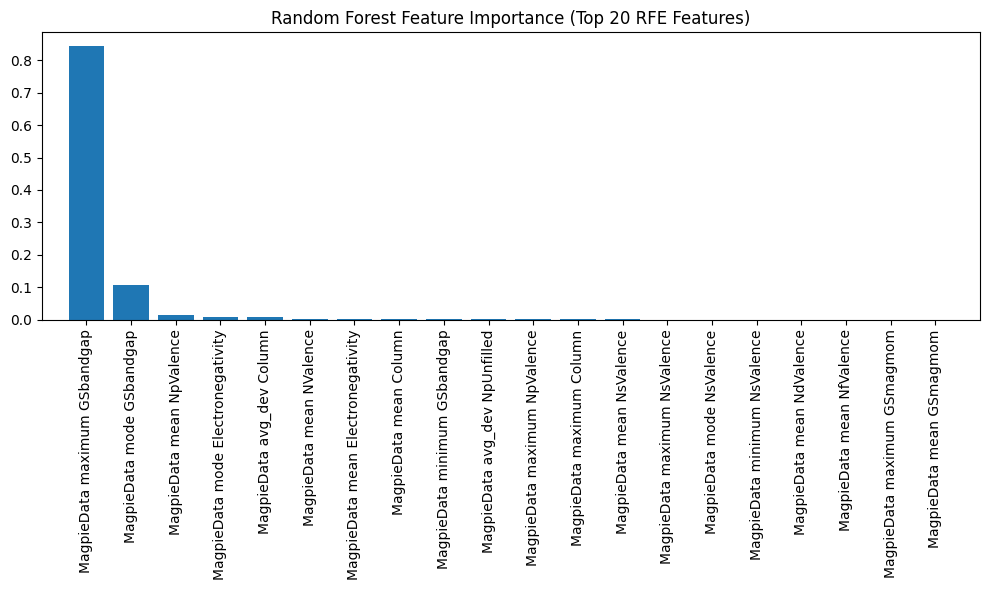

In [19]:
# 4. Preliminary Importance Bar Chart
plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importance (Top 20 RFE Features)")
plt.bar(range(X_rfe.shape[1]), importances[indices], align="center")
plt.xticks(range(X_rfe.shape[1]), top_features[indices], rotation=90)
plt.xlim([-1, X_rfe.shape[1]])
plt.tight_layout()
plt.show()

In [21]:
# 5. Save the final curated dataset

target_column = 'MagpieData mean GSbandgap'

# Keep the target and selected top features
df_curated = df[[target_column] + list(top_features)]

# Save the curated dataset
df_curated.to_csv('curated_features_s21.csv', index=False)

print("✅ Final curated feature set saved.")
print("Shape:", df_curated.shape)
print("Target:", target_column)

✅ Final curated feature set saved.
Shape: (4564, 21)
Target: MagpieData mean GSbandgap
